# 阻尼振子：前向欧拉法 vs 二阶龙格-库塔法（RK2）

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学
- 2026年9月24日

例 4 的无阻尼简谐振子里，前向欧拉法每步把能量放大 $1+z^2$ 倍——数值"负阻尼"，且对任何步长都无界。本例给振子加上**真实阻尼**（$c = 2m\beta$），物理开始耗散能量——数值误差与物理阻尼正面相遇，谁赢？

**运动方程**：

$$
\dot x = v, \qquad \dot v = -\omega_0^2 x - 2\beta v, \qquad \omega_0 = \sqrt{k/m}
$$

欠阻尼（$\beta < \omega_0$）时解析解

$$
x(t) = e^{-\beta t}\left(\cos\omega_d t + \frac{\beta}{\omega_d}\sin\omega_d t\right), \qquad
\omega_d = \sqrt{\omega_0^2 - \beta^2},
$$

振幅包络 $e^{-\beta t}$，能量包络 $E_0 e^{-2\beta t}$（$E_0 = \tfrac{1}{2}m\omega_0^2 x_0^2$，取 $v_0 = 0$）。RK2 仍用中点形式：先走半步估出中点状态，再用中点值走整步——与例 4 同一格式，只是右端多了 $-2\beta v$。

**运行之前，先把你的预测写下来**：

1. 例 4 里欧拉的能量只涨不跌。现在有真阻尼了：欧拉的能量曲线会掉头向下吗？衰减得比物理快还是慢？
2. RK2 能把衰减过程跟到多准？能量衰减也像例 4 那样有可解析预言的"每步定律"吗？
3. 速度相空间 $(x, v)$ 里的轨迹还是闭合椭圆吗？会变成什么样？

带着预测运行下面的代码，逐条对照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.interpolate import CubicSpline

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler_damped(h, n_steps):
    """前向欧拉：状态 (x, v)，右端全部用旧值"""
    x = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)
    x[0], v[0] = x0, v0
    for n in range(n_steps):
        x[n+1] = x[n] + h * v[n]
        v[n+1] = v[n] + h * (-omega0**2 * x[n] - 2 * beta * v[n])
    return x, v


def rk2_midpoint_damped(h, n_steps):
    """RK2 中点法：半步预估中点状态，再用中点斜率走整步"""
    x = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)
    x[0], v[0] = x0, v0
    for n in range(n_steps):
        v_mid = v[n] + 0.5 * h * (-omega0**2 * x[n] - 2 * beta * v[n])   # 中点速度
        x_mid  = x[n] + 0.5 * h * v[n]                                   # 中点位置
        x[n+1] = x[n] + h * v_mid                # 用中点斜率走整步
        v[n+1] = v[n] + h * (-omega0**2 * x_mid - 2 * beta * v_mid)
    return x, v


# 参数：欠阻尼振子
m = 1.0
omega0 = 1.0           # 固有角频率 (rad/s)
beta = 0.1             # 阻尼系数 (1/s)，beta < omega0：欠阻尼
x0, v0 = 1.0, 0.0      # 初条件
h = 0.05               # 时间步长 (s)
t_end = 60.0           # 总时间 (s)
z = omega0 * h         # 无量纲步长

wd = np.sqrt(omega0**2 - beta**2)   # 阻尼振动角频率
n_steps = int(t_end / h)
t = np.arange(n_steps + 1) * h

x_eu, v_eu = forward_euler_damped(h, n_steps)
x_rk, v_rk = rk2_midpoint_damped(h, n_steps)

# 解析解与包络
x_ex = np.exp(-beta * t) * (np.cos(wd * t) + (beta / wd) * np.sin(wd * t))
v_ex = -(omega0**2 / wd) * np.exp(-beta * t) * np.sin(wd * t)
env = np.exp(-beta * t)

# 能量 E = m(v² + ω₀²x²)/2
E_eu = 0.5 * m * (v_eu**2 + omega0**2 * x_eu**2)
E_rk = 0.5 * m * (v_rk**2 + omega0**2 * x_rk**2)
E_ex = 0.5 * m * (v_ex**2 + omega0**2 * x_ex**2)
E0 = 0.5 * m * omega0**2 * x0**2

# 渐近每步能量比（更新矩阵特征值的模方）
r_eu = 1 - 2 * beta * h + z**2            # 欧拉 |λ|²
w = (-beta + 1j * wd) * h
r_rk = abs(1 + w + w**2 / 2)**2           # RK2 |λ|²
r_ph = np.exp(-2 * beta * h)              # 物理 e^(-2βh)

beff_eu = -np.log(E_eu[-1] / E0) / (2 * t_end)
beff_rk = -np.log(E_rk[-1] / E0) / (2 * t_end)

print(f'参数：m = 1, ω₀ = {omega0}, β = {beta}（欠阻尼，ω_d = {wd:.6f}），x₀ = 1, v₀ = 0，h = {h} s（z = {z}），t = {t_end:.0f} s ≈ {t_end * wd / (2 * np.pi):.1f} 个周期，共 {n_steps} 步')
print(f'每步能量比（渐近，|λ|²）：物理 e^(-2βh) = {r_ph:.6f}，欧拉 1 − 2βh + z² = {r_eu:.6f}，RK2 |1+w+w²/2|² = {r_rk:.6f}')
print(f'等效阻尼 β_eff（全程实测）：物理 β = {beta}，欧拉 {beff_eu:.4f}（理论 β − ω₀²h/2 = {beta - 0.5 * omega0**2 * h:.4f}），RK2 {beff_rk:.5f}')
print(f'末能量 (J)：精确 {E_ex[-1]:.3e}，RK2 {E_rk[-1]:.3e}（差 {abs(E_rk[-1] / E_ex[-1] - 1):.1%}），欧拉 {E_eu[-1]:.3e}（精确解的 {E_eu[-1] / E_ex[-1]:.1f} 倍）')
print(f'稳定边界：h* = 2β/ω₀² = {2 * beta / omega0**2} s（当前 h = {h} s）')

参数：m = 1, ω₀ = 1.0, β = 0.1（欠阻尼，ω_d = 0.994987），x₀ = 1, v₀ = 0，h = 0.05 s（z = 0.05），t = 60 s ≈ 9.5 个周期，共 1200 步
每步能量比（渐近，|λ|²）：物理 e^(-2βh) = 0.990050，欧拉 1 − 2βh + z² = 0.992500，RK2 |1+w+w²/2|² = 0.990039
等效阻尼 β_eff（全程实测）：物理 β = 0.1，欧拉 0.0749（理论 β − ω₀²h/2 = 0.0750），RK2 0.10005
末能量 (J)：精确 3.078e-06，RK2 3.053e-06（差 0.8%），欧拉 6.269e-05（精确解的 20.4 倍）
稳定边界：h* = 2β/ω₀² = 0.2 s（当前 h = 0.05 s）


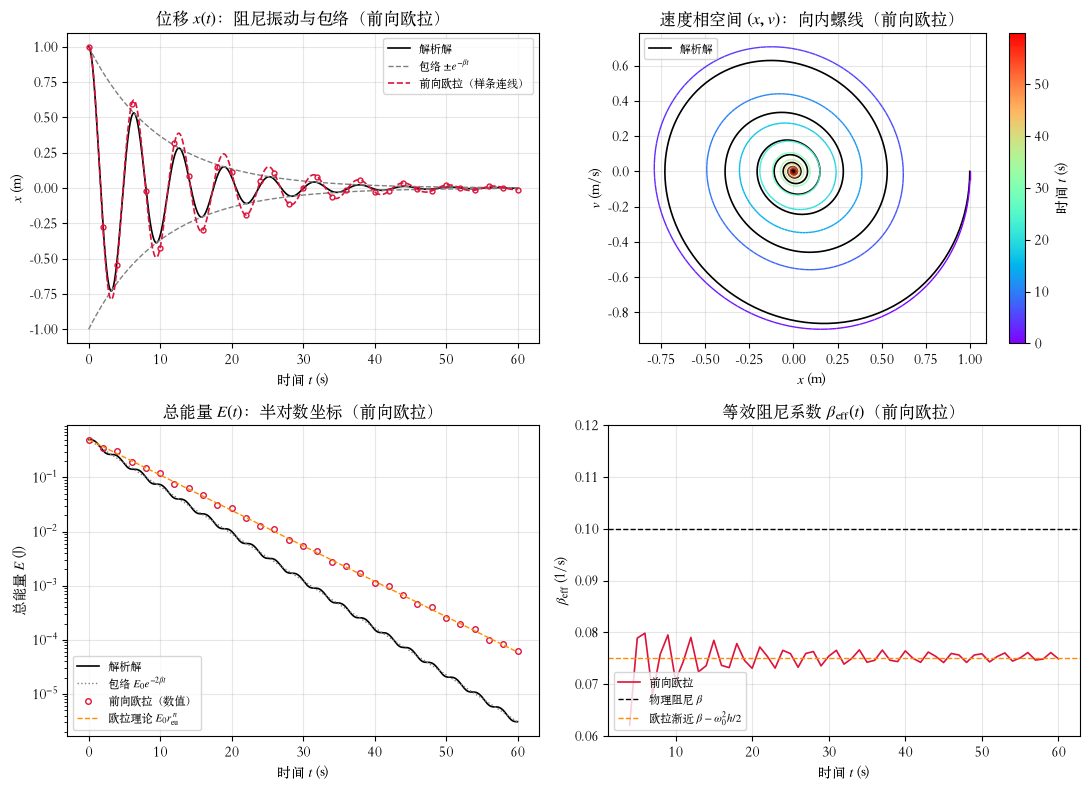

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(11, 8))

# (a) 位移时间序列
ax = axs[0, 0]
ax.plot(t, x_ex, 'k-', lw=1.2, label='解析解')
ax.plot(t, env, '--', color='gray', lw=1, label=r'包络 $\pm e^{-\beta t}$')
ax.plot(t, -env, '--', color='gray', lw=1)
cs_eu = CubicSpline(t, x_eu)
t_f = np.linspace(0.0, t_end, 800)
ax.plot(t_f, cs_eu(t_f), '--', color='crimson', lw=1.2, label='前向欧拉（样条连线）')
ax.plot(t, x_eu, 'o', color='crimson', ms=3.5, mfc='none', markevery=40)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('$x$ (m)')
ax.set_title('位移 $x(t)$：阻尼振动与包络（前向欧拉）')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)

# (b) 速度相空间：颜色随时间变
ax = axs[0, 1]
ax.plot(x_ex, v_ex, 'k-', lw=1.2, label='解析解')
pts = np.array([x_eu, v_eu]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap='rainbow', array=t[:-1], lw=1)
ax.add_collection(lc)
ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$v$ (m/s)')
ax.set_title('速度相空间 $(x, v)$：向内螺线（前向欧拉）')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
fig.colorbar(lc, ax=ax, label='时间 $t$ (s)')

# (c) 总能量（半对数）
ax = axs[1, 0]
steps = np.arange(n_steps + 1)
ax.semilogy(t, E_ex, 'k-', lw=1.2, label='解析解')
ax.semilogy(t, E0 * np.exp(-2 * beta * t), ':', color='gray', lw=1, label=r'包络 $E_0 e^{-2\beta t}$')
ax.semilogy(t, E_eu, 'o', color='crimson', ms=4, mfc='none', markevery=40, label='前向欧拉（数值）')
ax.semilogy(t, E0 * r_eu ** steps, '--', color='darkorange', lw=1, label=r'欧拉理论 $E_0 r_{\rm eu}^{\,n}$')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总能量 $E$ (J)')
ax.set_title('总能量 $E(t)$：半对数坐标（前向欧拉）')
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3)

# (d) 等效阻尼系数（累计估计）
ax = axs[1, 1]
sel = np.arange(int(4.0 / h), n_steps + 1, 20)
beff_eu_t = -np.log(E_eu[sel] / E0) / (2 * t[sel])
ax.plot(t[sel], beff_eu_t, '-', color='crimson', lw=1.2, label='前向欧拉')
ax.axhline(beta, color='k', ls='--', lw=1, label=r'物理阻尼 $\beta$')
ax.axhline(beta - 0.5 * omega0**2 * h, color='darkorange', ls='--', lw=1, label=r'欧拉渐近 $\beta - \omega_0^2 h/2$')
ax.set_ylim(0.06, 0.12)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel(r'$\beta_{\rm eff}$ (1/s)')
ax.set_title(r'等效阻尼系数 $\beta_{\rm eff}(t)$（前向欧拉）')
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/7_damped_oscillator_euler.pdf', bbox_inches='tight')
plt.show()

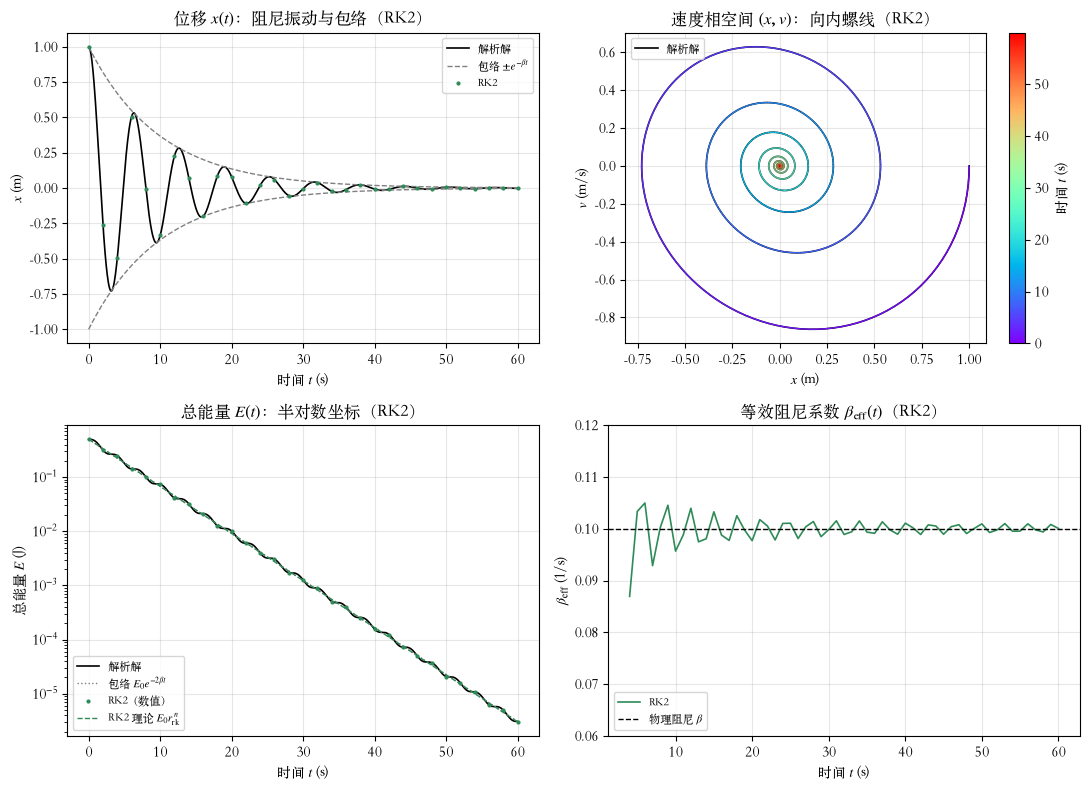

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(11, 8))

# (a) 位移时间序列
ax = axs[0, 0]
ax.plot(t, x_ex, 'k-', lw=1.2, label='解析解')
ax.plot(t, env, '--', color='gray', lw=1, label=r'包络 $\pm e^{-\beta t}$')
ax.plot(t, -env, '--', color='gray', lw=1)
ax.plot(t, x_rk, '.', color='seagreen', ms=4, markevery=40, label='RK2')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('$x$ (m)')
ax.set_title('位移 $x(t)$：阻尼振动与包络（RK2）')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)

# (b) 速度相空间：颜色随时间变
ax = axs[0, 1]
ax.plot(x_ex, v_ex, 'k-', lw=1.2, label='解析解')
pts = np.array([x_rk, v_rk]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap='rainbow', array=t[:-1], lw=1)
ax.add_collection(lc)
ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$v$ (m/s)')
ax.set_title('速度相空间 $(x, v)$：向内螺线（RK2）')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
fig.colorbar(lc, ax=ax, label='时间 $t$ (s)')

# (c) 总能量（半对数）
ax = axs[1, 0]
steps = np.arange(n_steps + 1)
ax.semilogy(t, E_ex, 'k-', lw=1.2, label='解析解')
ax.semilogy(t, E0 * np.exp(-2 * beta * t), ':', color='gray', lw=1, label=r'包络 $E_0 e^{-2\beta t}$')
ax.semilogy(t, E_rk, '.', color='seagreen', ms=4, markevery=40, label='RK2（数值）')
ax.semilogy(t, E0 * r_rk ** steps, '--', color='seagreen', lw=1, label=r'RK2 理论 $E_0 r_{\rm rk}^{\,n}$')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总能量 $E$ (J)')
ax.set_title('总能量 $E(t)$：半对数坐标（RK2）')
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3)

# (d) 等效阻尼系数（累计估计）
ax = axs[1, 1]
sel = np.arange(int(4.0 / h), n_steps + 1, 20)
beff_rk_t = -np.log(E_rk[sel] / E0) / (2 * t[sel])
ax.plot(t[sel], beff_rk_t, '-', color='seagreen', lw=1.2, label='RK2')
ax.axhline(beta, color='k', ls='--', lw=1, label=r'物理阻尼 $\beta$')
ax.set_ylim(0.06, 0.12)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel(r'$\beta_{\rm eff}$ (1/s)')
ax.set_title(r'等效阻尼系数 $\beta_{\rm eff}(t)$（RK2）')
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/7_damped_oscillator_rk2.pdf', bbox_inches='tight')
plt.show()

**对照预测**：

1. **欧拉终于肯衰减了——但衰减率被打折**：能量确实一路下降，斜率却只有物理的 3/4：$\beta_{\rm eff} = 0.075$（理论 $\beta - \omega_0^2 h/2$），60 s 后末能量是精确解的 20.4 倍。物理阻尼 $\beta = 0.1$ 与数值"负阻尼" $\omega_0^2 h/2 = 0.025$ 的净效果。
2. **RK2 贴住物理**：实测 $\beta_{\rm eff} = 0.10005$（物理 0.1），末能量与解析解只差 0.8%；渐近每步比 $r_{\rm rk} = 0.990039$ 对物理 $e^{-2\beta h} = 0.990050$，每步误差约万分之一。
3. **闭合椭圆变成向内螺线**：两条数值轨迹都旋进原点；欧拉的圈更"胖"（阻尼被打折，耗散得慢）、转得也略慢。
4. **新现象**（例 4、6 没有）：能量点并不逐位压在自己的理论虚线上，而是围绕虚线做 ±10% 的小幅摆动——阻尼把更新矩阵"变歪"了（下面细说）。但曲线的**斜率**仍严格由特征值预言。

## 为什么欧拉把阻尼"打折"，RK2 能还原？——特征值视角

把状态写成 $\boldsymbol{y} = (x, v)^{\!\top}$，右端矩阵 $A = \begin{pmatrix} 0 & 1 \\ -\omega_0^2 & -2\beta \end{pmatrix}$ 的特征值为 $\mu_\pm = -\beta \pm \mathrm{i}\,\omega_d$——实部 $-\beta$ 正是物理衰减率。

**前向欧拉**：$\boldsymbol{y}_{n+1} = (I + hA)\,\boldsymbol{y}_n$，特征值 $\lambda_\pm = 1 - \beta h \pm \mathrm{i}\,\omega_d h$：

$$
|\lambda|^2 = (1 - \beta h)^2 + \omega_d^2 h^2 = 1 - 2\beta h + h^2(\underbrace{\beta^2 + \omega_d^2}_{=\ \omega_0^2}) = 1 - 2\beta h + z^2
$$

$\beta^2$ **恰好消掉**：欧拉精确重现物理衰减的一阶项 $-2\beta h$，唯一误差仍是例 4 那个 $+z^2$——数值"负阻尼"原封不动地叠在真阻尼上。于是：

- 渐近衰减率 $\beta_{\rm eff} = \beta - \dfrac{\omega_0^2 h}{2}$：阻尼被折价，步长越大折得越狠（本例 0.1 → 0.075）；
- **稳定边界出现了**：$|\lambda| < 1 \iff h < 2\beta/\omega_0^2$。例 4 里"对任何步长都发散"的欧拉被阻尼救了回来——但一旦越界，数值负阻尼压过物理阻尼，能量越算越多（下一节亲眼验证）。

**RK2**：$\lambda_\pm = 1 + w + w^2/2$（$w = h\mu_\pm = -\beta h \pm \mathrm{i}\,\omega_d h$），展开：

$$
|\lambda|^2 = 1 - 2\beta h + 2\beta^2 h^2 + O(h^3)
$$

与物理每步比 $e^{-2\beta h} = 1 - 2\beta h + 2\beta^2 h^2 - \tfrac{4}{3}\beta^3 h^3 + \cdots$ 的偏差从 $h^3$ 项才开始——衰减率精确到 $O(h^2)$（实测 $\beta_{\rm eff} = 0.10005$），与例 4"误差小两个 $h^2$ 因子"同一结论。

**为什么不再"逐位"精确？** 无阻尼时 $I + hA$ 是"旋转 + 缩放"（正规矩阵），能量严格等比（例 4、6 逐位吻合）。阻尼一加，矩阵变歪（非正规），能量里出现两个特征模的**交叉项**——它以每步 $2\arg\lambda$ 的相位振荡、相对幅度不随时间衰减，于是数值能量永远围绕等比理论线小幅摆动（±10%，能量图中可见）。但**斜率**（渐近衰减率）仍严格由 $|\lambda|^2$ 决定——可解析预言的从"每一步的值"退到"整条曲线的趋势"。

## 大步长：越过稳定边界

把步长加大到 $h = 0.4$ s——是稳定边界 $h^* = 2\beta/\omega_0^2 = 0.2$ s 的**两倍**（每周期仅约 16 步），跑 $t = 30$ s ≈ 4.8 个周期。

**预测**：欧拉的能量还会衰减吗？RK2 还贴得住物理吗？

h = 0.4 s = 2 h*（每周期约 16 步），t = 30 s，共 75 步
欧拉每步能量比 1 − 2βh + z² = 1.0800 > 1：越阻尼越涨，末放大 3.49e+02 倍（理论 3.21e+02）
振幅：欧拉 |x| 最大 16 m（物理包络此刻只剩 0.050 m）


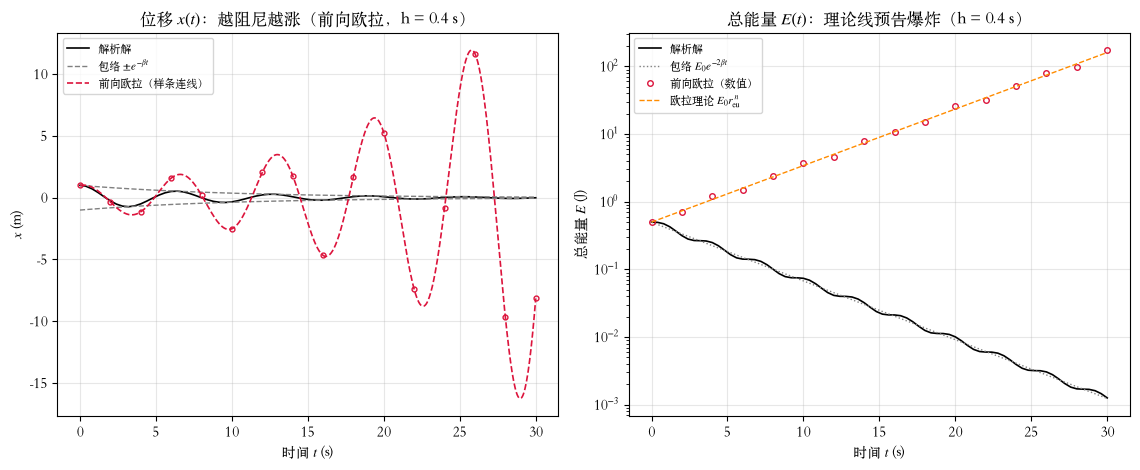

In [5]:
h_long = 0.4                  # 大步长 (s)，= 2 h*
t_long = 30.0                 # 总时间 (s)
n_long = int(t_long / h_long)
z_long = omega0 * h_long
t_l = np.arange(n_long + 1) * h_long
xl_ex = np.exp(-beta * t_l) * (np.cos(wd * t_l) + (beta / wd) * np.sin(wd * t_l))
vl_ex = -(omega0**2 / wd) * np.exp(-beta * t_l) * np.sin(wd * t_l)
El_ex = 0.5 * m * (vl_ex**2 + omega0**2 * xl_ex**2)
env_l = np.exp(-beta * t_l)
steps_l = np.arange(n_long + 1)

# 前向欧拉
xl_eu, vl_eu = forward_euler_damped(h_long, n_long)
El_eu = 0.5 * m * (vl_eu**2 + omega0**2 * xl_eu**2)
r_eu_l = 1 - 2 * beta * h_long + z_long**2

print(f'h = {h_long} s = 2 h*（每周期约 {2 * np.pi / wd / h_long:.0f} 步），t = {t_long:.0f} s，共 {n_long} 步')
print(f'欧拉每步能量比 1 − 2βh + z² = {r_eu_l:.4f} > 1：越阻尼越涨，末放大 {El_eu[-1] / E0:.2e} 倍（理论 {r_eu_l**n_long:.2e}）')
print(f'振幅：欧拉 |x| 最大 {np.abs(xl_eu).max():.0f} m（物理包络此刻只剩 {env_l.min():.3f} m）')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))

# (a) 位移：越阻尼越涨
ax1.plot(t_l, xl_ex, 'k-', lw=1.2, label='解析解')
ax1.plot(t_l, env_l, '--', color='gray', lw=1, label=r'包络 $\pm e^{-\beta t}$')
ax1.plot(t_l, -env_l, '--', color='gray', lw=1)
cs_eu_l = CubicSpline(t_l, xl_eu)
t_lf = np.linspace(0.0, t_long, 600)
ax1.plot(t_lf, cs_eu_l(t_lf), '--', color='crimson', lw=1.2, label='前向欧拉（样条连线）')
ax1.plot(t_l, xl_eu, 'o', color='crimson', ms=3.5, mfc='none', markevery=5)
ax1.set_xlabel('时间 $t$ (s)')
ax1.set_ylabel('$x$ (m)')
ax1.set_title(f'位移 $x(t)$：越阻尼越涨（前向欧拉，h = {h_long} s）')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(alpha=0.3)

# (b) 总能量（半对数）：理论线预告爆炸
ax2.semilogy(t_l, El_ex, 'k-', lw=1.2, label='解析解')
ax2.semilogy(t_l, E0 * np.exp(-2 * beta * t_l), ':', color='gray', lw=1, label=r'包络 $E_0 e^{-2\beta t}$')
ax2.semilogy(t_l, El_eu, 'o', color='crimson', ms=4, mfc='none', markevery=5, label='前向欧拉（数值）')
ax2.semilogy(t_l, E0 * r_eu_l ** steps_l, '--', color='darkorange', lw=1, label=r'欧拉理论 $E_0 r_{\rm eu}^{\,n}$')
ax2.set_xlabel('时间 $t$ (s)')
ax2.set_ylabel('总能量 $E$ (J)')
ax2.set_title(f'总能量 $E(t)$：理论线预告爆炸（h = {h_long} s）')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/7_damped_oscillator_euler_long.pdf', bbox_inches='tight')
plt.show()

RK2 每步能量比 = 0.923200 对物理 e^(-2βh) = 0.923116；末能量 1.134e-03 J 对精确 1.263e-03 J
振幅：RK2 |x| 最大 1.0000 m，贴包络衰减


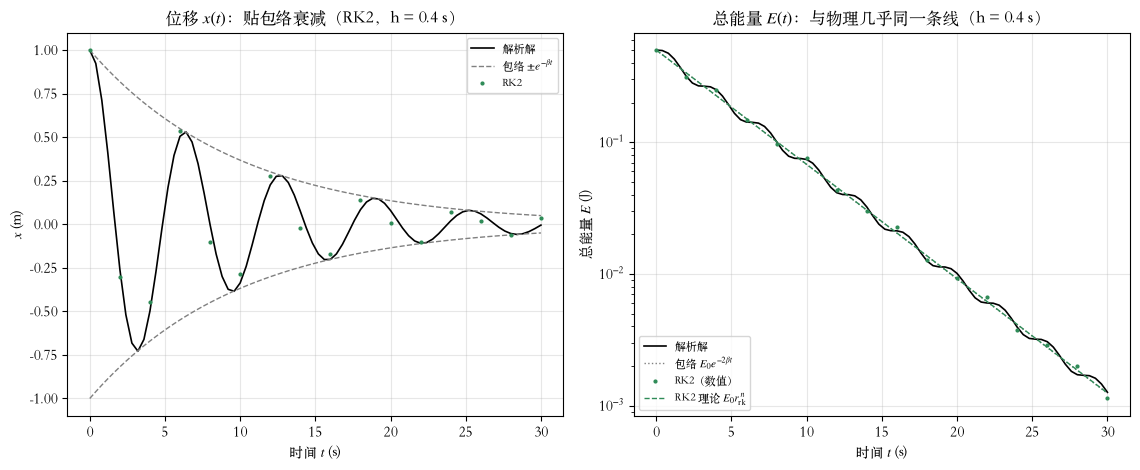

In [6]:
# RK2（共用上一格的大步长参数与解析解）
xl_rk, vl_rk = rk2_midpoint_damped(h_long, n_long)
El_rk = 0.5 * m * (vl_rk**2 + omega0**2 * xl_rk**2)
w_l = (-beta + 1j * wd) * h_long
r_rk_l = abs(1 + w_l + w_l**2 / 2)**2

print(f'RK2 每步能量比 = {r_rk_l:.6f} 对物理 e^(-2βh) = {np.exp(-2 * beta * h_long):.6f}；末能量 {El_rk[-1]:.3e} J 对精确 {El_ex[-1]:.3e} J')
print(f'振幅：RK2 |x| 最大 {np.abs(xl_rk).max():.4f} m，贴包络衰减')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))

# (a) 位移：贴包络衰减
ax1.plot(t_l, xl_ex, 'k-', lw=1.2, label='解析解')
ax1.plot(t_l, env_l, '--', color='gray', lw=1, label=r'包络 $\pm e^{-\beta t}$')
ax1.plot(t_l, -env_l, '--', color='gray', lw=1)
ax1.plot(t_l, xl_rk, '.', color='seagreen', ms=4, markevery=5, label='RK2')
ax1.set_xlabel('时间 $t$ (s)')
ax1.set_ylabel('$x$ (m)')
ax1.set_title(f'位移 $x(t)$：贴包络衰减（RK2，h = {h_long} s）')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(alpha=0.3)

# (b) 总能量（半对数）：与物理几乎同一条线
ax2.semilogy(t_l, El_ex, 'k-', lw=1.2, label='解析解')
ax2.semilogy(t_l, E0 * np.exp(-2 * beta * t_l), ':', color='gray', lw=1, label=r'包络 $E_0 e^{-2\beta t}$')
ax2.semilogy(t_l, El_rk, '.', color='seagreen', ms=4, markevery=5, label='RK2（数值）')
ax2.semilogy(t_l, E0 * r_rk_l ** steps_l, '--', color='seagreen', lw=1, label=r'RK2 理论 $E_0 r_{\rm rk}^{\,n}$')
ax2.set_xlabel('时间 $t$ (s)')
ax2.set_ylabel('总能量 $E$ (J)')
ax2.set_title(f'总能量 $E(t)$：与物理几乎同一条线（h = {h_long} s）')
ax2.legend(loc='lower left', fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/7_damped_oscillator_rk2_long.pdf', bbox_inches='tight')
plt.show()

**读图**：

1. **欧拉图**：振幅越滚越大（$|x|$ 冲上 16 m，而物理包络此刻只剩 0.05）——物理在耗散，数值在注能，且注得更快；能量点骑在理论线 $E_0(1.08)^n$ 上——特征值早就预告了爆炸（每步 $+8\%$，30 s 放大 300 余倍）。
2. **RK2 图**：振幅贴着 $e^{-\beta t}$ 包络衰减到百分之五；能量点骑在 $E_0 r_{\rm rk}^n$ 上，与物理包络几乎同一条线（每步比 0.9232 对 $e^{-0.08} = 0.9231$）。
3. **边界内外两个世界**：同一种方法，$h$ 从 0.05 到 0.4（从 $h^*/4$ 到 $2h^*$），欧拉从"衰减但打折"变成"越阻尼越涨"。数值负阻尼 $\omega_0^2 h/2$ 与物理阻尼 $\beta$ 的拔河，胜负完全由 $h \lessgtr 2\beta/\omega_0^2$ 裁决。

## 结论与思考

- **欧拉：衰减率打折**——渐近每步能量比 $1 - 2\beta h + z^2$ 精确重现物理一阶、错在 $+z^2$；等效阻尼 $\beta_{\rm eff} = \beta - \omega_0^2 h/2$（本例 0.1 → 0.075）。
- **稳定边界 $h^* = 2\beta/\omega_0^2$**——阻尼给了欧拉例 4 里不存在的稳定步长；越界则数值负阻尼反超物理阻尼，越阻尼越涨（$h = 0.4$ s 时 30 s 放大 300 余倍）。
- **RK2：衰减率精确到 $O(h^2)$**——渐近比 $|1 + w + w^2/2|^2$ 与物理 $e^{-2\beta h}$ 只差 $O(h^3)$；两个步长下都贴住物理。
- **逐位 → 趋势**：阻尼使更新矩阵非正规，能量围绕等比理论线永久小幅摆动；可解析预言的从"每一步的值"退到"整条曲线的斜率"。

**思考**：

1. 临界阻尼 $\beta = \omega_0$：$\omega_d = 0$，解析解变成 $(C_1 + C_2 t)\,e^{-\omega_0 t}$。特征值变成实数后，欧拉与 RK2 的渐近衰减率公式还成立吗？相图里的螺线变成什么形状？
2. 半隐式欧拉（先更新 $v$，再用**新** $v$ 更新 $x$）：对无阻尼振子它恰是纯旋转，能量严格守恒。写出阻尼情形的更新矩阵并求特征值：它的 $\beta_{\rm eff}$ 与稳定边界 $h^*$ 比显式欧拉好多少？
3. 取两组初条件 $(x_0, v_0) = (1, 0)$ 与 $(0, 1)$ 重跑本例：能量围绕理论线的**摆动幅度**变了吗？**渐近斜率**变了吗？（提示：摆动来自非正规矩阵的交叉项，依赖初条件；斜率只由特征值决定。）